# 基于傅立叶相位差推断交通图边方向

- 使用FFT计算相位差来估计时间延迟
- 多个日期分别计算，投票得出方向
- 与互相关方法对比

## 1. 环境配置

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "../output/edge_inference"
META_DIR = "../d03_meta_processed"
DATA_DIR = "/data/yuzhang_fei/PEMS/PEMSD3_2025"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("库加载完成！")

库加载完成！


## 2. 加载数据

In [2]:
# 加载交通流数据
print("加载交通流数据...")
flow_df = pd.read_csv(
    os.path.join(DATA_DIR, 'pems_5min_merged.csv'),
    dtype={'Station': str},
    parse_dates=['Timestamp']
)
print(f"交通流数据: {len(flow_df):,} 行")

# 加载 ML 传感器元数据
print("\n加载传感器元数据...")
meta_df = pd.read_csv(
    os.path.join(META_DIR, 'sensors_common_2025.csv'),
    dtype={'ID': str, 'Fwy': str}
)
ml_meta = meta_df[meta_df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_meta)}")

# 筛选 ML 传感器的流量数据
ml_ids = set(ml_meta['ID'])
flow_ml = flow_df[flow_df['Station'].isin(ml_ids)].copy()
print(f"ML 流量数据: {len(flow_ml):,} 行")

加载交通流数据...
交通流数据: 196,416,876 行

加载传感器元数据...
ML 传感器数: 854
ML 流量数据: 88,879,188 行


In [3]:
# 提取日期信息
flow_ml['Date'] = flow_ml['Timestamp'].dt.date
flow_ml['DayOfWeek'] = flow_ml['Timestamp'].dt.dayofweek  # 0=Mon
flow_ml['TimeSlot'] = flow_ml['Timestamp'].dt.hour * 12 + flow_ml['Timestamp'].dt.minute // 5

# 查看可用日期
available_dates = sorted(flow_ml['Date'].unique())
print(f"可用日期数: {len(available_dates)}")
print(f"日期范围: {available_dates[0]} ~ {available_dates[-1]}")

可用日期数: 363
日期范围: 2025-01-01 ~ 2025-12-31


## 3. 选择用于分析的日期

In [4]:
def select_analysis_dates(flow_ml, day_of_week=1, max_dates=12):
    """
    选择用于分析的日期
    day_of_week: 0=Mon, 1=Tue, ..., 6=Sun
    """
    dates_df = flow_ml[['Date', 'DayOfWeek']].drop_duplicates()
    target_dates = dates_df[dates_df['DayOfWeek'] == day_of_week]['Date'].tolist()
    target_dates = sorted(target_dates)
    
    if len(target_dates) > max_dates:
        step = len(target_dates) // max_dates
        selected = target_dates[::step][:max_dates]
    else:
        selected = target_dates
    
    return selected

In [ ]:
# 手动指定日期
selected_dates = [
    pd.Timestamp('2025-01-06').date(),
    pd.Timestamp('2025-01-07').date(),
    pd.Timestamp('2025-01-08').date(),
    pd.Timestamp('2025-01-09').date(),
    pd.Timestamp('2025-01-10').date(),
    pd.Timestamp('2025-01-11').date(),
    pd.Timestamp('2025-01-12').date()
]

## 4. 构建相邻传感器对

In [6]:
def build_adjacent_pairs(ml_meta):
    """
    构建相邻传感器对，确定理论方向
    """
    pairs = []
    
    for (fwy, direction), group in ml_meta.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]
            node2 = sorted_group.iloc[i + 1]
            
            distance = node2['Abs_PM'] - node1['Abs_PM']
            
            # 理论方向
            if direction in ['N', 'E']:
                source, target = node1['ID'], node2['ID']
            else:
                source, target = node2['ID'], node1['ID']
            
            pairs.append({
                'Node1': node1['ID'],
                'Node2': node2['ID'],
                'Fwy': fwy,
                'Dir': direction,
                'Distance': distance,
                'True_Source': source,
                'True_Target': target
            })
    
    return pd.DataFrame(pairs)


pairs_df = build_adjacent_pairs(ml_meta)
print(f"相邻传感器对数: {len(pairs_df)}")

相邻传感器对数: 814


## 5. 提取单日序列

In [7]:
def get_daily_series(flow_ml, station, date, metric='Total_Flow'):
    """
    获取某站点某天的原始时间序列（288点）
    """
    mask = (flow_ml['Station'] == station) & (flow_ml['Date'] == date)
    day_data = flow_ml[mask].sort_values('TimeSlot')
    
    if len(day_data) == 0:
        return None
    
    # 构建完整的 288 点序列（缺失填 NaN）
    series = np.full(288, np.nan)
    for _, row in day_data.iterrows():
        slot = int(row['TimeSlot'])
        if 0 <= slot < 288:
            series[slot] = row[metric]
    
    return series


# 测试
test_station = pairs_df.iloc[0]['Node1']
test_date = selected_dates[0]
test_series = get_daily_series(flow_ml, test_station, test_date)
print(f"测试序列 (Station={test_station}, Date={test_date}):")
print(f"  长度: {len(test_series)}")
print(f"  非空值: {np.sum(~np.isnan(test_series))}")
print(f"  前10个值: {test_series[:10]}")

测试序列 (Station=3034105, Date=2025-01-07):
  长度: 288
  非空值: 288
  前10个值: [0. 0. 0. 0. 0. 0. 0. 2. 0. 0.]


## 6. 傅立叶相位差计算

**原理**：
- 时移定理：若 B(t) = A(t - Δt)，则 FFT(B) = FFT(A) × e^(-j·2π·f·Δt)
- 相位差 Δφ(f) = φ_A(f) - φ_B(f) = 2π·f·Δt
- 时间延迟 Δt = Δφ / (2π·f) = Δφ / (2π) × T

In [8]:
def compute_lag_fft(series1, series2, target_periods=[288, 144, 96]):
    """
    使用傅立叶相位差计算时间延迟
    
    参数:
    - series1, series2: 时间序列（288点/天）
    - target_periods: 关注的周期（采样点数）
        - 288: 日周期（24h）
        - 144: 半日周期（12h）
        - 96: 8小时周期
    
    返回:
    - lag: 时间延迟（采样点数），正值表示 series1 领先
    - coherence: 平均相干性（0-1）
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    n = len(s1)
    if n < 50:
        return np.nan, np.nan
    
    if np.std(s1) < 1e-6 or np.std(s2) < 1e-6:
        return np.nan, np.nan
    
    # 去均值
    s1 = s1 - np.mean(s1)
    s2 = s2 - np.mean(s2)
    
    # FFT
    fft1 = np.fft.fft(s1)
    fft2 = np.fft.fft(s2)
    freqs = np.fft.fftfreq(n)
    
    # 交叉功率谱
    cross_spectrum = fft1 * np.conj(fft2)
    power1 = np.abs(fft1) ** 2
    power2 = np.abs(fft2) ** 2
    
    # 在目标周期上计算
    phase_diffs = []
    coherences = []
    weights = []
    
    for period in target_periods:
        if period > n:
            continue
        
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs[:n//2] - target_freq))
        
        if freq_idx == 0:
            continue
        
        # 相位差
        phase_diff = np.angle(cross_spectrum[freq_idx])
        
        # 相干性
        coh = np.abs(cross_spectrum[freq_idx]) ** 2 / (power1[freq_idx] * power2[freq_idx] + 1e-10)
        coh = np.sqrt(coh)
        
        # 能量权重
        energy = np.abs(cross_spectrum[freq_idx])
        
        if coh > 0.3:  # 只考虑相干性较高的频率
            phase_diffs.append(phase_diff)
            coherences.append(coh)
            weights.append(energy * coh)
    
    if len(phase_diffs) == 0:
        return np.nan, np.nan
    
    # 加权平均
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    avg_phase_diff = np.sum(np.array(phase_diffs) * weights)
    avg_coherence = np.sum(np.array(coherences) * weights)
    
    # 相位差转时间延迟（用日周期）
    dominant_period = target_periods[0]
    lag = avg_phase_diff / (2 * np.pi) * dominant_period
    
    # 限制范围（±半个周期）
    if lag > dominant_period / 2:
        lag -= dominant_period
    elif lag < -dominant_period / 2:
        lag += dominant_period
    
    return lag, avg_coherence

In [9]:
def analyze_pair_fft_multi_day(flow_ml, node1, node2, dates, metric='Total_Flow'):
    """
    多日 FFT 分析 + 投票
    """
    lags = []
    cohs = []
    
    for date in dates:
        s1 = get_daily_series(flow_ml, node1, date, metric)
        s2 = get_daily_series(flow_ml, node2, date, metric)
        lag, coh = compute_lag_fft(s1, s2)
        lags.append(lag)
        cohs.append(coh)
    
    # 筛选有效结果（相干性 > 0.3）
    valid_lags = [l for l, c in zip(lags, cohs) 
                  if not np.isnan(l) and not np.isnan(c) and c > 0.3]
    
    if len(valid_lags) == 0:
        return lags, cohs, np.nan, 'unknown'
    
    # 投票
    votes = []
    for l in valid_lags:
        if l > 0.5:  # 阈值：半个时间步
            votes.append(node1)
        elif l < -0.5:
            votes.append(node2)
    
    if len(votes) == 0:
        return lags, cohs, np.median(valid_lags), 'uncertain'
    
    vote_count = Counter(votes)
    pred_source, count = vote_count.most_common(1)[0]
    median_lag = np.median(valid_lags)
    
    # 一致性检验
    if count < len(votes) * 0.6:
        pred_source = 'uncertain'
    
    return lags, cohs, median_lag, pred_source

## 7. 批量分析

In [10]:
# 配置
METRIC = 'Total_Flow'  # 可选: 'Total_Flow', 'Avg_Speed', 'Avg_Occupancy'

print(f"配置:")
print(f"  使用指标: {METRIC}")
print(f"  分析日期数: {len(selected_dates)}")
print(f"  传感器对数: {len(pairs_df)}")

配置:
  使用指标: Total_Flow
  分析日期数: 1
  传感器对数: 814


In [11]:
def visualize_edge_fft(flow_ml, node1, node2, start_date, end_date, 
                       metric='Total_Flow', figsize=(14, 12)):
    """
    可视化一条边的傅立叶分析
    """
    # 转换日期
    if isinstance(start_date, str):
        start_date = pd.to_datetime(start_date).date()
    if isinstance(end_date, str):
        end_date = pd.to_datetime(end_date).date()
    
    # 筛选数据
    mask1 = (flow_ml['Station'] == node1) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    mask2 = (flow_ml['Station'] == node2) & (flow_ml['Date'] >= start_date) & (flow_ml['Date'] <= end_date)
    
    df1 = flow_ml[mask1][['Timestamp', metric]].set_index('Timestamp').sort_index()
    df2 = flow_ml[mask2][['Timestamp', metric]].set_index('Timestamp').sort_index()
    
    df_merged = pd.merge(df1, df2, left_index=True, right_index=True, how='inner', suffixes=('_1', '_2'))
    
    if len(df_merged) == 0:
        print(f"无数据")
        return np.nan, np.nan
    
    series1 = df_merged[f'{metric}_1'].values
    series2 = df_merged[f'{metric}_2'].values
    timestamps = df_merged.index
    
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask] - np.mean(series1[mask])
    s2 = series2[mask] - np.mean(series2[mask])
    n = len(s1)
    
    print(f"数据点数: {n}")
    
    # FFT
    fft1 = np.fft.fft(s1)
    fft2 = np.fft.fft(s2)
    freqs = np.fft.fftfreq(n)
    
    # 交叉功率谱
    cross_spectrum = fft1 * np.conj(fft2)
    phase_diff = np.angle(cross_spectrum)
    
    # 相干性
    power1 = np.abs(fft1) ** 2
    power2 = np.abs(fft2) ** 2
    coherence = np.abs(cross_spectrum) ** 2 / (power1 * power2 + 1e-10)
    coherence = np.sqrt(coherence)
    
    # 只看正频率
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    periods = 1 / freqs_pos
    periods_hours = periods / 12
    
    power1_pos = power1[pos_mask]
    phase_diff_pos = phase_diff[pos_mask]
    coherence_pos = coherence[pos_mask]
    
    # 计算延迟
    lag, coh = compute_lag_fft(series1, series2)
    
    # ========== 可视化 ==========
    fig, axes = plt.subplots(4, 1, figsize=figsize)
    
    # 1. 时间序列
    axes[0].plot(timestamps[:min(576, len(timestamps))], series1[:min(576, len(series1))], 
                 'b-', alpha=0.7, label=node1, linewidth=0.8)
    axes[0].plot(timestamps[:min(576, len(timestamps))], series2[:min(576, len(series2))], 
                 'r-', alpha=0.7, label=node2, linewidth=0.8)
    axes[0].set_ylabel(metric)
    axes[0].set_title(f'Time Series (First 2 Days)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. 功率谱
    axes[1].semilogy(periods_hours, power1_pos, 'b-', alpha=0.7, label=node1)
    axes[1].semilogy(periods_hours, power2[pos_mask], 'r-', alpha=0.7, label=node2)
    axes[1].axvline(x=24, color='green', linestyle='--', alpha=0.5, label='24h')
    axes[1].axvline(x=12, color='orange', linestyle='--', alpha=0.5, label='12h')
    axes[1].set_xlabel('Period (hours)')
    axes[1].set_ylabel('Power')
    axes[1].set_title('Power Spectrum')
    axes[1].set_xlim(0, 48)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. 相干性
    axes[2].plot(periods_hours, coherence_pos, 'g-', linewidth=1)
    axes[2].axvline(x=24, color='green', linestyle='--', alpha=0.5)
    axes[2].axvline(x=12, color='orange', linestyle='--', alpha=0.5)
    axes[2].axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Threshold')
    axes[2].set_xlabel('Period (hours)')
    axes[2].set_ylabel('Coherence')
    axes[2].set_title('Coherence Spectrum')
    axes[2].set_xlim(0, 48)
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # 4. 相位差
    sc = axes[3].scatter(periods_hours, phase_diff_pos, c=coherence_pos, cmap='viridis', s=10, alpha=0.7)
    axes[3].axvline(x=24, color='green', linestyle='--', alpha=0.5)
    axes[3].axvline(x=12, color='orange', linestyle='--', alpha=0.5)
    axes[3].axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    axes[3].set_xlabel('Period (hours)')
    axes[3].set_ylabel('Phase Difference (rad)')
    axes[3].set_title('Phase Difference (color = coherence)')
    axes[3].set_xlim(0, 48)
    axes[3].set_ylim(-np.pi, np.pi)
    plt.colorbar(sc, ax=axes[3], label='Coherence')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 结果
    print(f"\n{'='*50}")
    print(f"FFT 相位差分析结果")
    print(f"{'='*50}")
    print(f"时间延迟: {lag:.2f} 步 ({lag*5:.1f} 分钟)")
    print(f"平均相干性: {coh:.3f}")
    if lag > 0.5:
        print(f"→ {node1} 领先，方向: {node1} → {node2}")
    elif lag < -0.5:
        print(f"→ {node2} 领先，方向: {node2} → {node1}")
    else:
        print("→ 延迟接近0，无法判断方向")
    
    return lag, coh

示例: 3034105 vs 3085041
理论方向: 3034105 → 3085041
数据点数: 2016


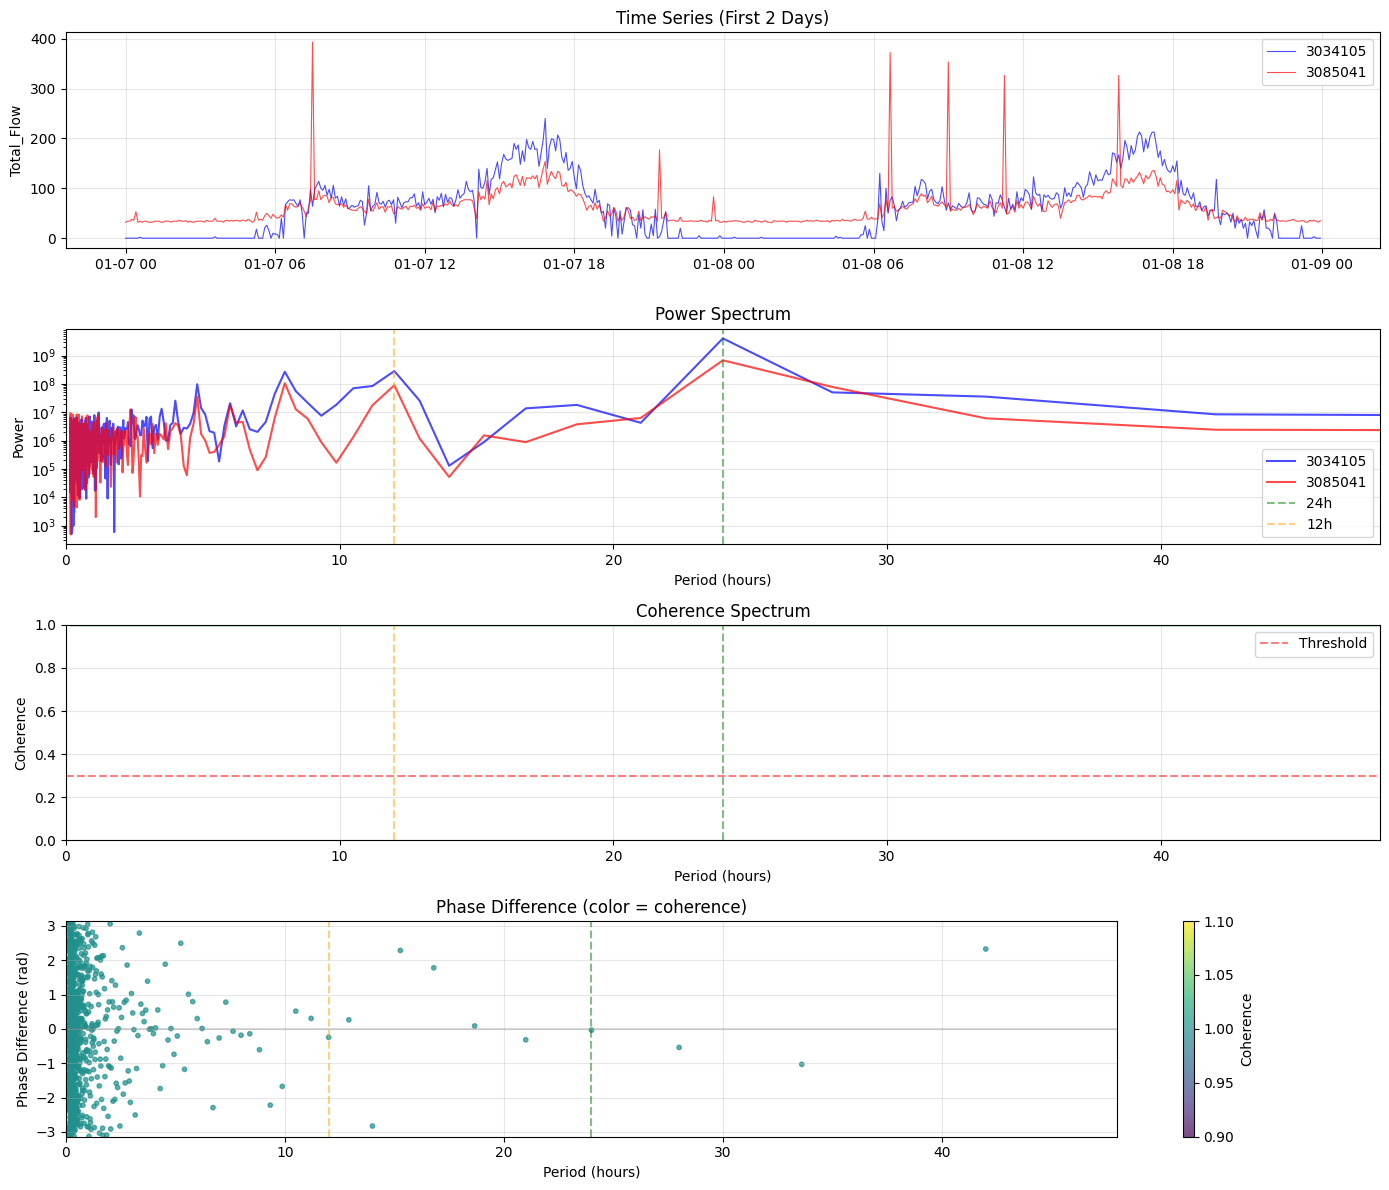


FFT 相位差分析结果
时间延迟: -3.05 步 (-15.2 分钟)
平均相干性: 1.000
→ 3085041 领先，方向: 3085041 → 3034105


In [12]:
# 可视化示例
sample_pair = pairs_df.iloc[0]
print(f"示例: {sample_pair['Node1']} vs {sample_pair['Node2']}")
print(f"理论方向: {sample_pair['True_Source']} → {sample_pair['True_Target']}")

lag, coh = visualize_edge_fft(
    flow_ml,
    node1=sample_pair['Node1'],
    node2=sample_pair['Node2'],
    start_date='2025-01-07',
    end_date='2025-01-13',
    metric=METRIC
)

In [13]:
# print("\n开始批量分析...")

# results = []

# for idx, row in pairs_df.iterrows():
#     node1, node2 = row['Node1'], row['Node2']
    
#     lags, cohs, median_lag, pred_source = analyze_pair_fft_multi_day(
#         flow_ml, node1, node2, selected_dates, METRIC
#     )
    
#     result = {
#         'Node1': node1,
#         'Node2': node2,
#         'Fwy': row['Fwy'],
#         'Dir': row['Dir'],
#         'Distance': row['Distance'],
#         'True_Source': row['True_Source'],
#         'Pred_Source': pred_source,
#         'Median_Lag': median_lag,
#         'Valid_Days': sum(1 for l, c in zip(lags, cohs) 
#                          if not np.isnan(l) and not np.isnan(c) and c > 0.3)
#     }
    
#     # 添加每天的结果
#     for i, date in enumerate(selected_dates):
#         result[f'Lag_{i+1}'] = lags[i] if i < len(lags) else np.nan
#         result[f'Coh_{i+1}'] = cohs[i] if i < len(cohs) else np.nan
    
#     results.append(result)
    
#     if (idx + 1) % 50 == 0:
#         print(f"已处理 {idx + 1}/{len(pairs_df)}")

# results_df = pd.DataFrame(results)
# print(f"\n分析完成！")
# ============================================================
# 优化后的 FFT 批量分析代码
# 插入位置：替换原 notebook 中 "## 7. 批量分析" 部分的批量分析代码
# ============================================================

## 7. 批量分析（优化版）

### 7.1 构建数据缓存

# 构建 pivot 表加速查询
print("构建数据索引...")
flow_pivot = flow_ml.pivot_table(
    index=['Station', 'Date'],
    columns='TimeSlot',
    values='Total_Flow',  # 可改为 METRIC
    aggfunc='first'
)
print(f"Pivot 表形状: {flow_pivot.shape}")

### 7.2 优化后的 FFT 计算函数

def compute_lag_fft_fast(series1, series2, target_periods=[288, 144, 96]):
    """
    FFT 相位差计算（输入为 numpy array）
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    n = len(s1)
    if n < 50:
        return np.nan, np.nan
    
    std1, std2 = np.std(s1), np.std(s2)
    if std1 < 1e-6 or std2 < 1e-6:
        return np.nan, np.nan
    
    # 去均值
    s1 = s1 - np.mean(s1)
    s2 = s2 - np.mean(s2)
    
    # FFT
    fft1 = np.fft.fft(s1)
    fft2 = np.fft.fft(s2)
    freqs = np.fft.fftfreq(n)
    
    # 交叉功率谱
    cross_spectrum = fft1 * np.conj(fft2)
    power1 = np.abs(fft1) ** 2
    power2 = np.abs(fft2) ** 2
    
    phase_diffs = []
    coherences = []
    weights = []
    
    for period in target_periods:
        if period > n:
            continue
        
        target_freq = 1.0 / period
        freq_idx = np.argmin(np.abs(freqs[:n//2] - target_freq))
        
        if freq_idx == 0:
            continue
        
        phase_diff = np.angle(cross_spectrum[freq_idx])
        coh = np.abs(cross_spectrum[freq_idx]) ** 2 / (power1[freq_idx] * power2[freq_idx] + 1e-10)
        coh = np.sqrt(coh)
        energy = np.abs(cross_spectrum[freq_idx])
        
        if coh > 0.3:
            phase_diffs.append(phase_diff)
            coherences.append(coh)
            weights.append(energy * coh)
    
    if len(phase_diffs) == 0:
        return np.nan, np.nan
    
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    avg_phase_diff = np.sum(np.array(phase_diffs) * weights)
    avg_coherence = np.sum(np.array(coherences) * weights)
    
    dominant_period = target_periods[0]
    lag = avg_phase_diff / (2 * np.pi) * dominant_period
    
    if lag > dominant_period / 2:
        lag -= dominant_period
    elif lag < -dominant_period / 2:
        lag += dominant_period
    
    return lag, avg_coherence

### 7.3 批量分析函数

def analyze_all_pairs_fft_fast(flow_pivot, pairs_df, selected_dates):
    """
    批量 FFT 分析（优化版）
    """
    n_pairs = len(pairs_df)
    n_dates = len(selected_dates)
    
    # 预分配结果数组
    all_lags = np.full((n_pairs, n_dates), np.nan)
    all_cohs = np.full((n_pairs, n_dates), np.nan)
    
    # 预提取所有需要的序列
    print("提取序列到缓存...")
    series_cache = {}
    all_stations = set(pairs_df['Node1'].tolist() + pairs_df['Node2'].tolist())
    
    for station in all_stations:
        for date in selected_dates:
            key = (station, date)
            try:
                if key in flow_pivot.index:
                    series_cache[key] = flow_pivot.loc[key].values
                else:
                    series_cache[key] = None
            except:
                series_cache[key] = None
    
    print(f"缓存序列数: {len(series_cache)}")
    
    # 批量计算
    print("计算 FFT 相位差...")
    for i, row in pairs_df.iterrows():
        node1, node2 = row['Node1'], row['Node2']
        
        for j, date in enumerate(selected_dates):
            s1 = series_cache.get((node1, date))
            s2 = series_cache.get((node2, date))
            
            if s1 is not None and s2 is not None:
                lag, coh = compute_lag_fft_fast(s1, s2)
                all_lags[i, j] = lag
                all_cohs[i, j] = coh
        
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{n_pairs}")
    
    # 汇总结果
    print("汇总结果...")
    results = []
    
    for i, row in pairs_df.iterrows():
        lags = all_lags[i]
        cohs = all_cohs[i]
        
        # 筛选有效（相干性 > 0.3）
        valid_mask = (~np.isnan(lags)) & (~np.isnan(cohs)) & (cohs > 0.3)
        valid_lags = lags[valid_mask]
        
        if len(valid_lags) == 0:
            median_lag = np.nan
            pred_source = 'unknown'
        else:
            median_lag = np.median(valid_lags)
            
            # 投票
            pos_votes = np.sum(valid_lags > 0.5)
            neg_votes = np.sum(valid_lags < -0.5)
            total_votes = pos_votes + neg_votes
            
            if total_votes == 0:
                pred_source = 'uncertain'
            elif pos_votes > total_votes * 0.6:
                pred_source = row['Node1']
            elif neg_votes > total_votes * 0.6:
                pred_source = row['Node2']
            else:
                pred_source = 'uncertain'
        
        result = {
            'Node1': row['Node1'],
            'Node2': row['Node2'],
            'Fwy': row['Fwy'],
            'Dir': row['Dir'],
            'Distance': row['Distance'],
            'True_Source': row['True_Source'],
            'Pred_Source': pred_source,
            'Median_Lag': median_lag,
            'Valid_Days': int(np.sum(valid_mask))
        }
        
        # 每天的结果
        for j in range(n_dates):
            result[f'Lag_{j+1}'] = lags[j]
            result[f'Coh_{j+1}'] = cohs[j]
        
        results.append(result)
    
    return pd.DataFrame(results)

### 7.4 执行分析

# 配置
METRIC = 'Total_Flow'

print(f"配置:")
print(f"  使用指标: {METRIC}")
print(f"  分析日期数: {len(selected_dates)}")
print(f"  传感器对数: {len(pairs_df)}")

# 运行优化版分析
print(f"\n开始分析...")
results_df = analyze_all_pairs_fft_fast(flow_pivot, pairs_df, selected_dates)
print("分析完成！")

构建数据索引...


Pivot 表形状: (309934, 288)
配置:
  使用指标: Total_Flow
  分析日期数: 1
  传感器对数: 814

开始分析...
提取序列到缓存...
缓存序列数: 850
计算 FFT 相位差...
  100/814
  200/814
  300/814
  400/814
  500/814
  600/814
  700/814
  800/814
汇总结果...
分析完成！


## 8. 评估精度

In [14]:
# 判断正确性
results_df['Correct'] = results_df['Pred_Source'] == results_df['True_Source']

# 统计
total = len(results_df)
uncertain = (results_df['Pred_Source'] == 'uncertain').sum()
unknown = (results_df['Pred_Source'] == 'unknown').sum()
valid = results_df[~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
correct = results_df['Correct'].sum()

print("=" * 60)
print("FFT 相位差方法 - 精度评估")
print("=" * 60)
print(f"总传感器对数: {total}")
print(f"有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)")
print(f"不确定数: {uncertain} ({uncertain/total*100:.1f}%)")
print(f"无数据数: {unknown} ({unknown/total*100:.1f}%)")
print(f"\n正确预测数: {correct}")
print(f"整体精度: {correct/total*100:.1f}%")
if len(valid) > 0:
    print(f"有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%")

FFT 相位差方法 - 精度评估
总传感器对数: 814
有效预测数: 619 (76.0%)
不确定数: 195 (24.0%)
无数据数: 0 (0.0%)

正确预测数: 333
整体精度: 40.9%
有效预测精度: 53.8%


In [15]:
# 按方向统计
print("\n按方向统计:")
dir_stats = results_df.groupby('Dir').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dir_stats.columns = ['正确数', '总数', '精度']
display(dir_stats)


按方向统计:


,正确数,总数,精度
Dir,,,
E,80,229,0.349
N,84,178,0.472
S,75,185,0.405
W,94,222,0.423


In [16]:
# 按距离统计
print("\n按距离统计:")
results_df['Dist_Bin'] = pd.cut(
    results_df['Distance'],
    bins=[0, 0.5, 1, 2, 5, 100],
    labels=['<0.5mi', '0.5-1mi', '1-2mi', '2-5mi', '>5mi']
)
dist_stats = results_df.groupby('Dist_Bin').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dist_stats.columns = ['正确数', '总数', '精度']
display(dist_stats)


按距离统计:


,正确数,总数,精度
Dist_Bin,,,
<0.5mi,110,310,0.355
0.5-1mi,86,220,0.391
1-2mi,50,112,0.446
2-5mi,39,78,0.500
>5mi,39,69,0.565


In [17]:
# 按有效天数统计
print("\n按有效天数统计:")
valid_day_stats = results_df.groupby('Valid_Days').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
valid_day_stats.columns = ['正确数', '总数', '精度']
display(valid_day_stats)


按有效天数统计:


,正确数,总数,精度
Valid_Days,,,
1,333,814,0.409


## 9. 可视化

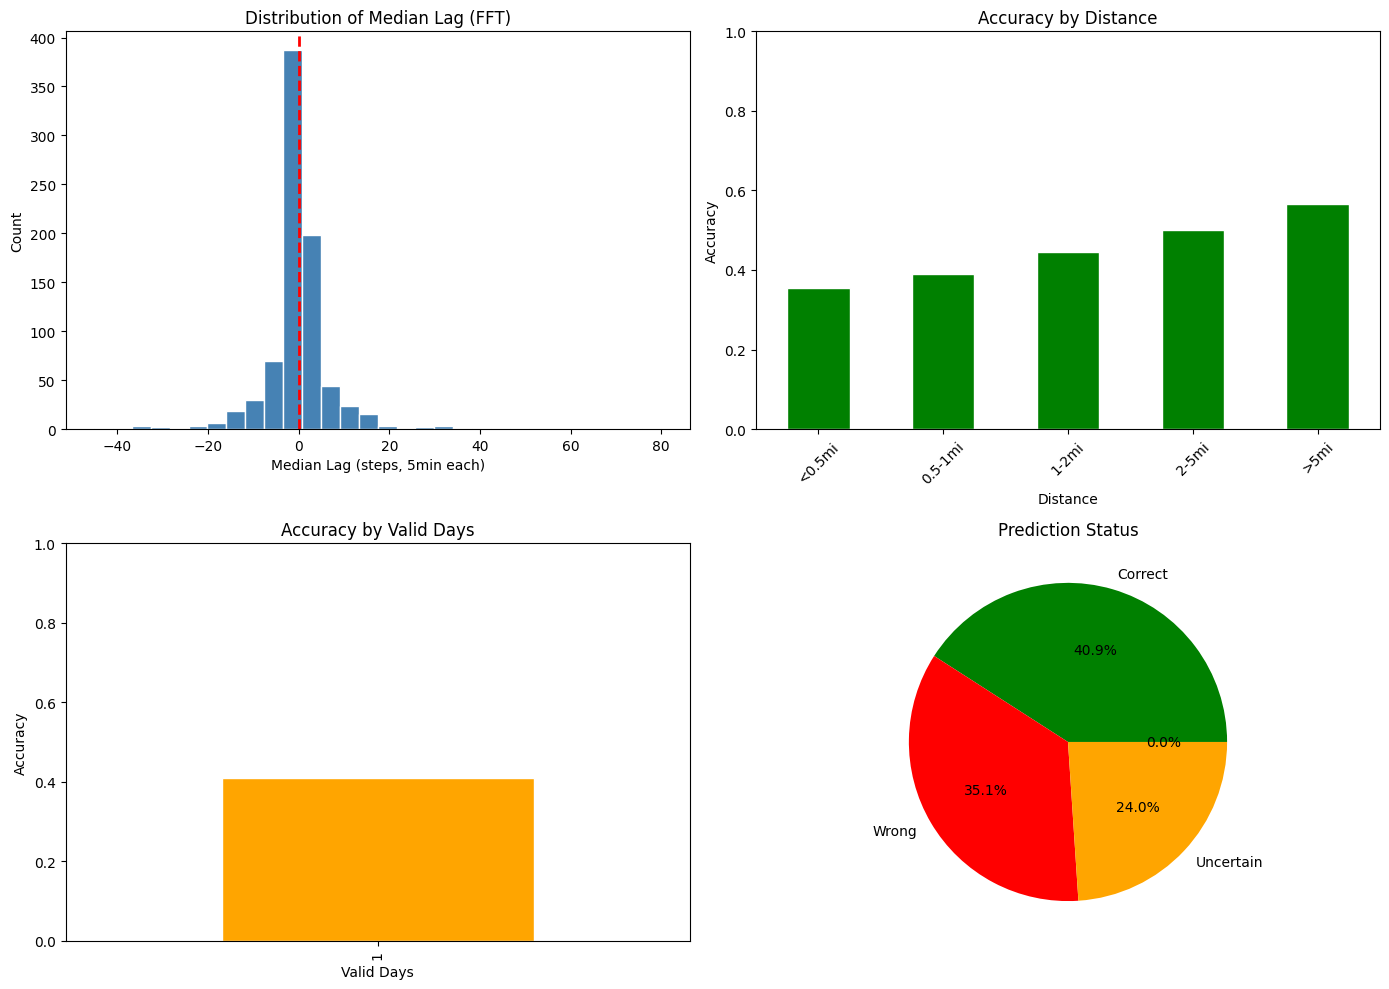

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 滞后分布
valid_lags = results_df['Median_Lag'].dropna()
axes[0, 0].hist(valid_lags, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Median Lag (steps, 5min each)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Distribution of Median Lag (FFT)')

# 2. 精度 vs 距离
dist_acc = results_df.groupby('Dist_Bin')['Correct'].mean()
dist_acc.plot(kind='bar', ax=axes[0, 1], color='green', edgecolor='white')
axes[0, 1].set_xlabel('Distance')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy by Distance')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
axes[0, 1].set_ylim(0, 1)

# 3. 精度 vs 有效天数
valid_day_acc = results_df.groupby('Valid_Days')['Correct'].mean()
valid_day_acc.plot(kind='bar', ax=axes[1, 0], color='orange', edgecolor='white')
axes[1, 0].set_xlabel('Valid Days')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy by Valid Days')
axes[1, 0].set_ylim(0, 1)

# 4. 预测状态分布
status_counts = pd.Series({
    'Correct': correct,
    'Wrong': len(valid) - valid['Correct'].sum() if len(valid) > 0 else 0,
    'Uncertain': uncertain,
    'Unknown': unknown
})
status_counts.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', 
                   colors=['green', 'red', 'orange', 'gray'])
axes[1, 1].set_ylabel('')
axes[1, 1].set_title('Prediction Status')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'direction_inference_fft.png'), dpi=150)
plt.show()

In [19]:
# 查看具体案例
print("\n预测正确的案例:")
display(results_df[results_df['Correct']][['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 
                                            'Median_Lag', 'Valid_Days']].head(10))

print("\n预测错误的案例:")
wrong = results_df[~results_df['Correct'] & ~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
display(wrong[['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 'Median_Lag', 
               'Valid_Days', 'True_Source', 'Pred_Source']].head(10))


预测正确的案例:


,Node1,Node2,Fwy,Dir,Distance,Median_Lag,Valid_Days
2,316482,3415046,113,N,28.241,2.706269,1
5,3085044,3034034,113,S,5.024,-4.338382,1
6,3034034,3415047,113,S,28.255,-23.751112,1
18,3413064,314521,160,N,36.372,14.825337,1
21,3069011,3410018,162,E,18.008,2.509834,1
22,3069012,3410017,162,W,18.012,-2.546395,1
24,3090051,3022012,20,E,9.246,5.456345,1
26,3085061,3423018,20,E,26.306,5.996543,1
28,3422011,3422102,20,E,0.723,5.116040,1
29,3422102,3422031,20,E,0.393,2.389819,1



预测错误的案例:


,Node1,Node2,Fwy,Dir,Distance,Median_Lag,Valid_Days,True_Source,Pred_Source
0,3034105,3085041,113,N,3.983,-2.927481,1,3034105,3085041
1,3085041,316482,113,N,5.030,-3.243303,1,3085041,316482
4,3034101,3085044,113,S,3.980,1.841186,1,3085044,3034101
7,3415047,3415044,113,S,0.049,11.019510,1,3415044,3415047
14,3010012,3413054,12,W,0.358,17.160501,1,3413054,3010012
19,3413061,314580,160,S,36.370,0.735245,1,314580,3413061
20,314580,314159,160,S,0.691,1.140294,1,314159,314580
23,3022022,3090051,20,E,2.684,-6.255552,1,3022022,3090051
25,3022012,3085061,20,E,19.398,-3.592224,1,3022012,3085061
27,3423018,3422011,20,E,1.294,-6.838377,1,3423018,3422011


## 10. 保存结果

In [20]:
# 保存完整结果
output_path = os.path.join(OUTPUT_DIR, 'direction_inference_fft.csv')
results_df.to_csv(output_path, index=False)
print(f"结果已保存: {output_path}")

# 保存摘要
summary = f"""
边方向推断结果摘要（FFT相位差方法）
====================================

配置:
- 使用指标: {METRIC}
- 目标周期: 24h, 12h, 8h
- 相干性阈值: 0.3
- 分析日期数: {len(selected_dates)}

分析日期:
{chr(10).join(str(d) for d in selected_dates)}

结果:
- 总传感器对数: {total}
- 有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)
- 不确定数: {uncertain} ({uncertain/total*100:.1f}%)
- 无数据数: {unknown} ({unknown/total*100:.1f}%)

精度:
- 整体精度: {correct/total*100:.1f}%
- 有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}% (如果有效预测数>0)

按方向:
{dir_stats.to_string()}

按距离:
{dist_stats.to_string()}
"""

with open(os.path.join(OUTPUT_DIR, 'direction_inference_fft_summary.txt'), 'w') as f:
    f.write(summary)
print(f"摘要已保存: direction_inference_fft_summary.txt")

结果已保存: ../output/edge_inference/direction_inference_fft.csv
摘要已保存: direction_inference_fft_summary.txt


---
## 说明

### FFT 相位差方法原理
1. 时移定理：若 B(t) = A(t - Δt)，则 FFT(B) = FFT(A) × e^(-j·2π·f·Δt)
2. 相位差 Δφ(f) = φ_A(f) - φ_B(f)
3. 时间延迟 Δt = Δφ / (2π) × T

### 与互相关方法的区别
| 方面 | 互相关 | FFT相位差 |
|------|--------|----------|
| 原理 | 时域滑动匹配 | 频域相位比较 |
| 输出 | 离散滞后步数 | 连续时间延迟 |
| 噪声处理 | 全频段 | 可选择特定频率 |
| 适用场景 | 通用 | 周期性信号更佳 |

### 输出文件
| 文件 | 说明 |
|------|------|
| `direction_inference_fft.csv` | 完整结果 |
| `direction_inference_fft_summary.txt` | 精度摘要 |
| `direction_inference_fft.png` | 统计图 |